## Initial load

In [78]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
from folium.plugins import MarkerCluster

In [79]:
missed_pickups = pd.read_csv('../data/missed_pickups_rme.csv')

In [80]:
missed_pickups

,Unnamed: 0,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y,LONGITUDE,LATITUDE,Street Address,Building Number,Street
0,0,25274,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,Red River,4202,1.0,1.721259e+06,685444.799565,-86.838103,36.213470,4028 Clarksville Pike,4028,Clarksville Pike
1,1,25276,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209.0,Red River,4205,20.0,1.707027e+06,659887.471571,-86.885562,36.142923,6528 Thunderbird Dr,6528,Thunderbird Dr
2,2,25307,11/01/17,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,Waste Ind,2206,2.0,1.735692e+06,685027.245923,-86.789170,36.212652,2603 Old Matthews Rd,2603,Old Matthews Rd
3,3,25312,11/01/17,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209.0,Red River,4203,20.0,1.710186e+06,664205.101066,-86.874995,36.154861,604 Croley Dr,604,Croley Dr
4,4,25327,11/01/17,Trash Collection Complaint,"Trash out on time, miss again Tuesday. ALLEY",1816 Jo Johnston Ave,37203.0,Metro,9208,21.0,1.731459e+06,666013.601229,-86.802988,36.160330,1816 Jo Johnston Ave,1816,Jo Johnston Ave
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17738,17738,267121,11/01/19,Trash - Curbside/Alley Missed Pickup,missed,"2709 Crestdale Dr, Nashville, TN 37214, United...",37214.0,Red River,1502,15.0,1.770240e+06,676334.399319,-86.671860,36.189483,2709 Crestdale Dr,2709,Crestdale Dr
17739,17739,267125,11/01/19,Trash - Curbside/Alley Missed Pickup,MISSED...NEIGHBORS MISSED,2731 Murfreesboro Pike,37013.0,Red River,4502,32.0,1.781137e+06,632448.551144,-86.633970,36.069130,2731 Murfreesboro Pike,2731,Murfreesboro Pike
17740,17740,267126,11/01/19,Trash - Curbside/Alley Missed Pickup,entire alley,"1621 Long Ave, Nashville, TN 37206, United States",37206.0,Metro,9508,6.0,1.749711e+06,669201.601569,-86.741242,36.169482,1621 Long Ave,1621,Long Ave
17741,17741,267130,11/01/19,Trash - Curbside/Alley Missed Pickup,missed several,"2943 Windemere Cir, Nashville, TN 37214, Unite...",37214.0,Red River,1502,15.0,1.770293e+06,674936.303809,-86.671647,36.185643,2943 Windemere Cir,2943,Windemere Cir


In [81]:
zip_codes = gpd.read_file('../data/zipcodes.geojson')

In [82]:
addresses = missed_pickups.groupby('Street Address').agg({'LONGITUDE': 'mean', 'LATITUDE': 'mean', 'Zip Code': 'max', 'Date Opened': 'count', 'Trash Hauler': ', '.join}).reset_index()

In [83]:
for i, r in addresses.iterrows():
    haulers = r['Trash Hauler'].split(', ')
    haul_list = []
    
    for hauler in haulers:
        if hauler not in haul_list:
            haul_list.append(hauler)
    
    if (len(haul_list) >= 2) & ('No hauler identified' in haul_list):
        haul_list.remove('No hauler identified')        

    addresses.loc[i, 'Trash Hauler'] = ', '.join(haul_list)

In [84]:
addresses

,Street Address,LONGITUDE,LATITUDE,Zip Code,Date Opened,Trash Hauler
0,1 Belle Forrest Ave C,-86.733905,36.193409,37206.0,1,Metro
1,10 Belle Forrest Ave,-86.734668,36.193906,37206.0,1,Metro
2,100 Bluefield Square,-86.670995,36.163465,37214.0,1,Red River
3,100 Braxton Hill Ct,-86.794435,36.091422,37204.0,1,Red River
4,100 Brook Hollow Rd,-86.881589,36.095062,37205.0,1,Red River
...,...,...,...,...,...,...
11615,98 Oceola Ave,-86.859330,36.142110,37209.0,1,Red River
11616,986 Malquin Dr,-86.728899,36.230260,37216.0,2,Red River
11617,99 Farris Ave,-86.687760,36.262290,37115.0,1,Red River
11618,994 Dozier Pl,-86.743980,36.203008,37216.0,1,Metro


In [85]:
addresses['Trash Hauler'].value_counts()

Trash Hauler
Red River               8531
Metro                   2015
Waste Ind                781
No hauler identified     291
Red River, Metro           2
Name: count, dtype: int64

In [86]:
addresses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11620 entries, 0 to 11619
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Street Address  11620 non-null  object 
 1   LONGITUDE       11612 non-null  float64
 2   LATITUDE        11612 non-null  float64
 3   Zip Code        11589 non-null  float64
 4   Date Opened     11620 non-null  int64  
 5   Trash Hauler    11620 non-null  object 
dtypes: float64(3), int64(1), object(2)
memory usage: 544.8+ KB


## Mapping time!

### Mapping addresses with multiple missed pickups

Reconfigure data:

In [87]:
multi_missed = addresses.loc[addresses['Date Opened'] > 1].sort_values('Date Opened', ascending = False).reset_index(drop = True)

In [88]:
multi_missed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3157 entries, 0 to 3156
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Street Address  3157 non-null   object 
 1   LONGITUDE       3157 non-null   float64
 2   LATITUDE        3157 non-null   float64
 3   Zip Code        3157 non-null   float64
 4   Date Opened     3157 non-null   int64  
 5   Trash Hauler    3157 non-null   object 
dtypes: float64(3), int64(1), object(2)
memory usage: 148.1+ KB


8 rows don't contain latitude/longitude :/ dropping them, I guess

In [89]:
multi_missed

,Street Address,LONGITUDE,LATITUDE,Zip Code,Date Opened,Trash Hauler
0,110 George L Davis Blvd,-86.789073,36.156693,37203.0,27,Metro
1,5135 Hickory Hollow Pkwy,-86.665685,36.049931,37013.0,23,Red River
2,3710 N Natchez Ct,-86.734906,36.094576,37211.0,20,Red River
3,12546 Old Hickory Blvd,-86.604537,36.036257,37013.0,20,Red River
4,1584 Bell Rd,-86.697731,36.044047,37211.0,19,Red River
...,...,...,...,...,...,...
3152,2813 27Th Ave S,-86.811297,36.124633,37212.0,2,Red River
3153,2813 Delaware Ave B,-86.820018,36.155428,37209.0,2,Metro
3154,2813 Gear St,-86.746563,36.203247,37216.0,2,Metro
3155,2813 Penn Meade Dr,-86.702619,36.239088,37214.0,2,Red River


In [90]:
multi_missed['Date Opened'].describe()

count    3157.000000
mean        2.939500
std         1.864164
min         2.000000
25%         2.000000
50%         2.000000
75%         3.000000
max        27.000000
Name: Date Opened, dtype: float64

In [91]:
multi_missed['color'] = pd.cut(multi_missed['Date Opened'], [0, 2, 5, 10, 20, 100], labels = ['green', 'orange', 'red', 'darkred', 'darkpurple'])

Find center for folium map

In [92]:
map_center = [multi_missed.LATITUDE.mean(), multi_missed.LONGITUDE.mean()]

In [97]:
top_addresses = multi_missed.head(100)

In [110]:
zoom_center = [top_addresses.LATITUDE.mean(), (top_addresses.LONGITUDE.mean())]
top_address_map = folium.Map(location =  zoom_center, zoom_start = 11)

for i, r in top_addresses.iterrows():
    loc =  loc = [r['LATITUDE'], r['LONGITUDE']]
    pop = r['Trash Hauler']
    icon = folium.Icon(color = r['color'], icon = 'dumpster', prefix = 'fa')

    marker = folium.Marker(location = loc, popup = pop, icon = icon)
    marker.add_to(top_address_map)

top_address_map.save('../top_missed_addresses_rme.html')
top_address_map

In [114]:
top_streets = missed_pickups.groupby(['Street', 'Zip Code'], as_index = False).agg(missed = ('Request Number', 'count')).sort_values('missed', ascending = False).head(10)

In [115]:
top_streets['Street']

675       Buena Vista Pike
1656     Granny White Pike
2798      Old Hickory Blvd
1298          Eastland Ave
268              Annex Ave
1388              Estes Rd
274           Antioch Pike
1630          Golf Club Ln
1744            Harding Pl
906       Clarksville Pike
Name: Street, dtype: object

In [117]:
loc_on_top_streets = missed_pickups.loc[missed_pickups['Street'].isin(top_streets['Street'])]

In [120]:
zoom_center = [loc_on_top_streets.LATITUDE.mean(), (loc_on_top_streets.LONGITUDE.mean())]
top_streets_map = folium.Map(location =  zoom_center, zoom_start = 11)

for i, r in loc_on_top_streets.iterrows():
    loc =  loc = [r['LATITUDE'], r['LONGITUDE']]
    pop = r['Trash Hauler']
    icon = folium.Icon(color = 'darkred', icon = 'dumpster', prefix = 'fa')

    marker = folium.Marker(location = loc, popup = pop, icon = icon)
    marker.add_to(top_streets_map)

top_streets_map.save('../top_missed_streets_rme.html')
top_streets_map

In [53]:
nashville_cluster = folium.Map(location =  map_center, zoom_start = 11)
marker_cluster = MarkerCluster().add_to(nashville_cluster)

for i, r in multi_missed.iterrows():
    loc = [r['LATITUDE'], r['LONGITUDE']]
    pop = r['Trash Hauler']
    icon = folium.Icon(color = r['color'], icon = 'dumpster', prefix = 'fa')

    marker = folium.Marker(location = loc, popup = pop, icon = icon)
    marker.add_to(marker_cluster)

nashville_cluster

### By zip code

In [54]:
zip_misses = addresses.groupby('Zip Code').agg(count = ('Date Opened', 'sum'), avg_misses = ('Date Opened', 'mean'), max_misses = ('Date Opened', 'max')).reset_index()

In [55]:
for i, r in zip_misses.iterrows():
    haulers = missed_pickups.loc[missed_pickups['Zip Code'] == r['Zip Code'], 'Trash Hauler']
    haul_list = []
    
    for hauler in haulers:
        if hauler not in haul_list:
            haul_list.append(hauler)

    if ('No hauler identified' in haul_list) & (len(haul_list) >= 2):
        haul_list.remove('No hauler identified')

    zip_misses.loc[i, 'Haulers'] = ', '.join(haul_list)

In [56]:
zip_misses['Zip Code'] = zip_misses['Zip Code'].astype(int).astype(str)

In [57]:
zip_merge = pd.merge(zip_codes, zip_misses, how = 'outer' , left_on = 'zip', right_on = 'Zip Code')

In [58]:
zip_merge['avg_misses'] = zip_merge['avg_misses'].round(2).fillna(0)

In [59]:
zip_merge['max_misses'] = zip_merge['max_misses'].fillna(0).astype(int)

In [60]:
zip_merge['count'] = zip_merge['count'].fillna(0).astype(int)

In [61]:
zip_merge[['count', 'avg_misses', 'max_misses']].describe()

,count,avg_misses,max_misses
count,56.000000,56.000000,56.000000
mean,356.357143,0.986607,6.625000
std,526.949624,0.717628,6.732722
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,99.500000,1.330000,7.000000
75%,613.750000,1.520000,11.000000
max,2055.000000,2.200000,27.000000


In [62]:
zip_merge.sort_values('count', ascending = False).head(2)

,zip,objectid,po_name,shape_stlength,shape_starea,geometry,Zip Code,count,avg_misses,max_misses,Haulers
0,37013,34,ANTIOCH,349164.88029162859,1150567551.5894165,"MULTIPOLYGON (((-86.66517 36.09108, -86.66526 ...",37013,2055,1.50,23,"Red River, Metro"
42,37211,39,NASHVILLE,290587.58467925159,602215091.79736328,"MULTIPOLYGON (((-86.75696 36.13189, -86.75693 ...",37211,1995,1.52,20,"Red River, Metro, Waste Ind"


In [63]:
zip_merge.sort_values('avg_misses', ascending = False).head(2)

,zip,objectid,po_name,shape_stlength,shape_starea,geometry,Zip Code,count,avg_misses,max_misses,Haulers
50,37219,15,NASHVILLE,21013.192337432083,6579013.4385986328,"MULTIPOLYGON (((-86.78609 36.17465, -86.78585 ...",37219,33,2.20,11,"Metro, Waste Ind, Red River"
32,37201,14,NASHVILLE,25670.555742711778,11151362.94934082,"MULTIPOLYGON (((-86.77973 36.17460, -86.77823 ...",37201,29,2.07,6,"Metro, Waste Ind"


In [64]:
zip_merge.sort_values('max_misses', ascending = False).head(2)

,zip,objectid,po_name,shape_stlength,shape_starea,geometry,Zip Code,count,avg_misses,max_misses,Haulers
33,37203,33,NASHVILLE,91285.438580354588,120649702.5546875,"MULTIPOLYGON (((-86.78734 36.16688, -86.78711 ...",37203,343,1.73,27,"Metro, Waste Ind"
0,37013,34,ANTIOCH,349164.88029162859,1150567551.5894165,"MULTIPOLYGON (((-86.66517 36.09108, -86.66526 ...",37013,2055,1.50,23,"Red River, Metro"


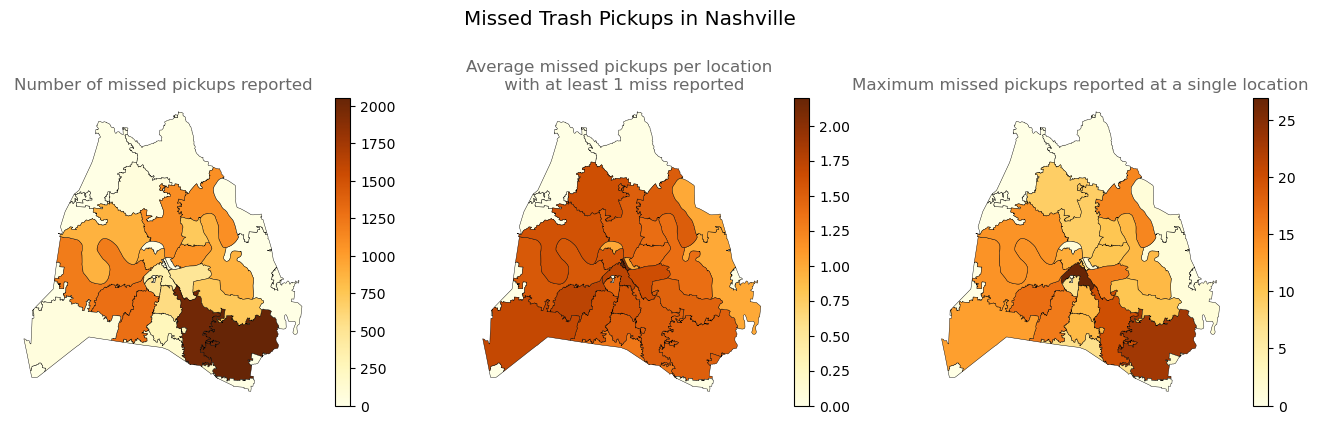

In [65]:
cols_interest = [{'column': 'count', 'title': 'Number of missed pickups reported'}, 
                 {'column': 'avg_misses', 'title': 'Average missed pickups per location \n with at least 1 miss reported'},
                 {'column': 'max_misses', 'title': 'Maximum missed pickups reported at a single location'}]

fig, axs = plt.subplots(1, 3, figsize = (8, 4))
plt.subplots_adjust(right = 1.75)


for col_num in range(3):
    axis = axs[col_num]
    zip_merge.plot(column = cols_interest[col_num].get('column'),
              edgecolor = 'black',
               linewidth = .3,
              legend = True,
              cmap = 'YlOrBr',
              ax = axis)
    axis.axis('off')
    axis.set_title(cols_interest[col_num].get('title'), color = 'dimgray')

fig.suptitle('Missed Trash Pickups in Nashville', y = 1.1, x = .9, fontsize = 'x-large')
plt.show();

### Haulers by zip code

table w/columns: hauler, zip code, num misses/avg_misses/max_misses

two maps showing where each hauler's misses are focused - same zip codes or different zip codes?

In [66]:
addresses['Hauler List'] = addresses['Trash Hauler'].str.split(', ')

In [67]:
haul_zip = addresses.explode('Hauler List').groupby(['Hauler List', 'Zip Code'], as_index = False).agg(count = ('Date Opened', 'sum'), avg_misses = ('Date Opened', 'mean'), max_misses = ('Date Opened', 'max'))

In [68]:
haul_zip

,Hauler List,Zip Code,count,avg_misses,max_misses
0,Metro,37013.0,1,1.000000,1
1,Metro,37201.0,20,2.500000,6
2,Metro,37203.0,265,1.815068,27
3,Metro,37204.0,229,1.496732,8
4,Metro,37205.0,99,1.546875,8
...,...,...,...,...,...
70,Waste Ind,37210.0,240,1.589404,16
71,Waste Ind,37211.0,7,1.166667,2
72,Waste Ind,37213.0,1,1.000000,1
73,Waste Ind,37216.0,1,1.000000,1


In [69]:
haul_zip['Zip Code'] = haul_zip['Zip Code'].astype(int).astype(str)

Need to get a list of all haulers x all zip codes, to map zip codes with 0 values

In [70]:
unique_haulers = ['Red River', 'Metro', 'Waste Ind', 'No hauler identified']

In [71]:
cross_merge = pd.merge(pd.DataFrame(zip_codes.zip), pd.DataFrame(unique_haulers), how = 'cross')

In [72]:
cross_merge

,zip,0
0,37115,Red River
1,37115,Metro
2,37115,Waste Ind
3,37115,No hauler identified
4,37216,Red River
...,...,...
219,37122,No hauler identified
220,37152,Red River
221,37152,Metro
222,37152,Waste Ind


Now let's add on our missed pickup data from haul_zip:

In [73]:
merge1 = pd.merge(haul_zip, cross_merge, how = 'right', right_on = ['zip', 0], left_on = ['Zip Code', 'Hauler List'])

In [74]:
merge1

,Hauler List,Zip Code,count,avg_misses,max_misses,zip,0
0,Red River,37115,1052.0,1.547059,15.0,37115,Red River
1,Metro,NaN,NaN,NaN,NaN,37115,Metro
2,Waste Ind,NaN,NaN,NaN,NaN,37115,Waste Ind
3,No hauler identified,37115,37.0,1.000000,1.0,37115,No hauler identified
4,Red River,37216,571.0,1.423940,10.0,37216,Red River
...,...,...,...,...,...,...,...
219,No hauler identified,NaN,NaN,NaN,NaN,37122,No hauler identified
220,Red River,NaN,NaN,NaN,NaN,37152,Red River
221,Metro,NaN,NaN,NaN,NaN,37152,Metro
222,Waste Ind,NaN,NaN,NaN,NaN,37152,Waste Ind


Then add on the geographic data from zip_codes

In [75]:
haul_merge = pd.merge(zip_codes, merge1, how = 'right', on = 'zip')

In [76]:
haul_merge['avg_misses'] = haul_merge['avg_misses'].round(2).fillna(0)
haul_merge['max_misses'] = haul_merge['max_misses'].fillna(0).astype(int)
haul_merge['count'] = haul_merge['count'].fillna(0).astype(int)

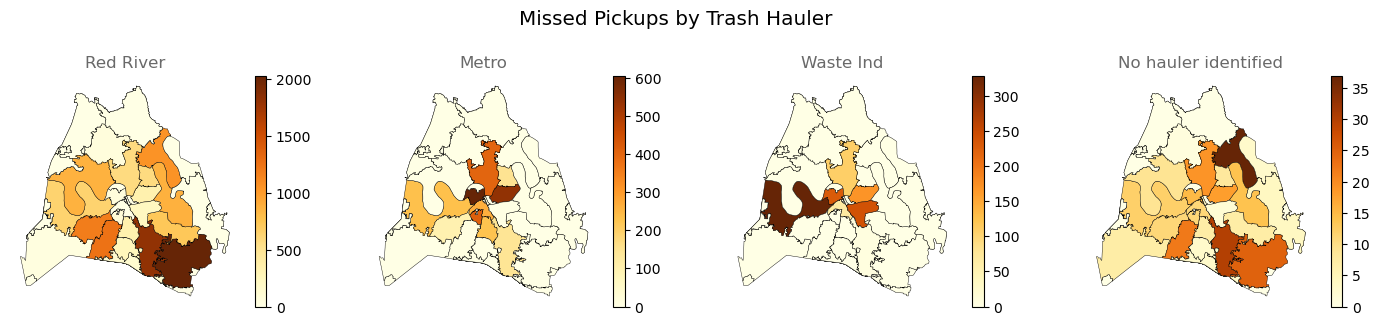

In [77]:
fig, axs = plt.subplots(1, len(unique_haulers), figsize = (10, 3))
plt.subplots_adjust(right = 1.5)

## make the maps
col_num = 0
for hauler in unique_haulers:
    df = haul_merge.loc[haul_merge[0] == hauler]
    
    axis = axs[col_num]
    df.plot(column = 'count',
            edgecolor = 'black',
            linewidth = .3,
            legend = True,
            cmap = 'YlOrBr',
            ax = axis)
    axis.axis('off')
    axis.set_title(hauler, color = 'dimgray')

    col_num += 1


fig.suptitle('Missed Pickups by Trash Hauler', y = 1.1, x = .8, fontsize = 'x-large')

plt.show();